Note: this notebook aims to run the pipeline of modeling, model_training, model_tuning and model_evaluation, and make conclusion in the end.

### 1. Data Loading

In [1]:
import pandas as pd
from CreditCardApproval.data import load_data

processed_df = load_data(return_type="processed")

In [2]:
# brief look
print("processed_df shape:", processed_df.shape)
processed_df.head()

processed_df shape: (36457, 18)


,ID,gender,own_car,own_realty,children_number,annual_income,own_work_phone,own_phone,own_email,family_size,age_years,is_unemployed,employed_years,income_type,education_level,family_status,housing_status,target
0,5008804,M,Y,Y,0,427500.0,1,0,0,2.0,32.867899,0,12.435318,Employed,Higher,Married,Rental,0
1,5008805,M,Y,Y,0,427500.0,1,0,0,2.0,32.867899,0,12.435318,Employed,Higher,Married,Rental,0
2,5008806,M,Y,Y,0,112500.0,0,0,0,2.0,58.792608,0,3.104723,Employed,Secondary,Married,Own_Home,0
3,5008808,F,N,Y,0,270000.0,0,1,1,1.0,52.320329,0,8.353183,Employed,Secondary,Single,Own_Home,0
4,5008809,F,N,Y,0,270000.0,0,1,1,1.0,52.320329,0,8.353183,Employed,Secondary,Single,Own_Home,0


In [3]:
print("Is ID unique:", processed_df["ID"].is_unique)
processed_df.info()

Is ID unique: True
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               36457 non-null  int64  
 1   gender           36457 non-null  object 
 2   own_car          36457 non-null  object 
 3   own_realty       36457 non-null  object 
 4   children_number  36457 non-null  int64  
 5   annual_income    36457 non-null  float64
 6   own_work_phone   36457 non-null  int64  
 7   own_phone        36457 non-null  int64  
 8   own_email        36457 non-null  int64  
 9   family_size      36457 non-null  float64
 10  age_years        36457 non-null  float64
 11  is_unemployed    36457 non-null  int64  
 12  employed_years   36457 non-null  float64
 13  income_type      36457 non-null  object 
 14  education_level  36457 non-null  object 
 15  family_status    36457 non-null  object 
 16  housing_status   36457 non-null  object

***

### 2. Modeling

##### ① Specify X and y

In [4]:
from CreditCardApproval.modeling import make_X_y, summarize_target

X, y = make_X_y(processed_df)
summarize_target(y)

,count,proportion
target,,
0,35841,0.983103
1,616,0.016897


##### ② Configuration and feature schema

In [5]:
from CreditCardApproval.modeling import FINAL_SCHEMA, validate_schema

validate_schema(processed_df, FINAL_SCHEMA)

##### ③ Build up model pipeline

In [6]:
from CreditCardApproval.modeling import make_glm_pipeline, make_lgbm_pipeline

glm_pipe = make_glm_pipeline(
    schema=FINAL_SCHEMA,
    log_income=True,
    income_col="annual_income",
)
glm_pipe

,steps,"[('log_income', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,columns,['annual_income']
,add_suffix,True
,suffix,'_log1p'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None


In [7]:
lgbm_pipe = make_lgbm_pipeline(
    schema=FINAL_SCHEMA,
    log_income=True,
    income_col="annual_income",
)
lgbm_pipe

,steps,"[('log_income', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,columns,['annual_income']
,add_suffix,True
,suffix,'_log1p'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None


##### ④ Preview pipeline dimension

In [8]:
from CreditCardApproval.modeling import preview_pipeline_dimensions

glm_preview = preview_pipeline_dimensions(glm_pipe, X)
print("GLM model pipeline preview:")
glm_preview

GLM model pipeline preview:


{'n_features_after_preprocess': 26,
 'n_samples_preview': 2000,
 'preview_rows_used': 2000,
 'columns_after_fe_preview': ['gender',
  'own_car',
  'own_realty',
  'children_number',
  'annual_income',
  'own_work_phone',
  'own_phone',
  'own_email',
  'family_size',
  'age_years',
  'is_unemployed',
  'employed_years',
  'income_type',
  'education_level',
  'family_status',
  'housing_status',
  'annual_income_log1p']}

In [9]:
lgbm_preview = preview_pipeline_dimensions(lgbm_pipe, X)
print("LGBM model pipeline preview:")
lgbm_preview

LGBM model pipeline preview:


{'n_features_after_preprocess': 26,
 'n_samples_preview': 2000,
 'preview_rows_used': 2000,
 'columns_after_fe_preview': ['gender',
  'own_car',
  'own_realty',
  'children_number',
  'annual_income',
  'own_work_phone',
  'own_phone',
  'own_email',
  'family_size',
  'age_years',
  'is_unemployed',
  'employed_years',
  'income_type',
  'education_level',
  'family_status',
  'housing_status',
  'annual_income_log1p']}

Review:

The preview confirms that both the GLM and LGBM pipelines produce the same feature dimensionality after preprocessing. This indicates that feature engineering steps, including categorical encoding and numerical transformations, are applied consistently across models, ensuring a fair comparison in subsequent training and evaluation.

***

### 3. Model Training

The aim of this part is to train model based on specified parameter, using different sampling methods.

In [10]:
from CreditCardApproval.model_training import split_data

X_train, X_val, y_train, y_val = split_data(X, y)

In [11]:
from CreditCardApproval.model_training import train_glm, train_lgbm, run_training_all_sampling

# GLM: baseline + 3 sampling
glm_models_fixed, glm_train_auc_table = run_training_all_sampling(
    "glm", X_train, y_train, X_val, y_val
)

# LGBM: baseline + 3 sampling
lgbm_models_fixed, lgbm_train_auc_table = run_training_all_sampling(
    "lgbm", X_train, y_train, X_val, y_val
)

pd.concat([glm_train_auc_table, lgbm_train_auc_table], axis=0).reset_index(drop=True)

Training GLM | sampling=baseline
Validation AUC = 0.5359

Training GLM | sampling=smote
After applying SMOTE, sample number: 57344, positive proportion: 50.00%
Validation AUC = 0.4310

Training GLM | sampling=undersample
After applying Undersample, sample number: 986, positive proportion: 50.00%
Validation AUC = 0.4519

Training GLM | sampling=combined
After applying Combined, sample number: 1972, positive proportion: 50.00%
Validation AUC = 0.4685

Training LGBM | sampling=baseline
[LightGBM] [Info] Number of positive: 493, number of negative: 28672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003353 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 896
[LightGBM] [Info] Number of data points in the train set: 29165, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016904 -> initscore=-4.063167
[LightGBM] 

,model,sampling,val_auc
0,GLM,baseline,0.535868
1,GLM,combined,0.468488
2,GLM,undersample,0.451935
3,GLM,smote,0.430952
4,LGBM,baseline,0.740954
5,LGBM,undersample,0.708700
6,LGBM,combined,0.668393
7,LGBM,smote,0.612847


Review:

Results indicate that:
1) The LGBM model demonstrated significantly superior overall discrimination capability compared to GLM and The LGBM baseline model achieved the highest validation set AUC.
2) GLM generally performed poorly across different sampling methods, with its discrimination capability further declining after applying SMOTE or undersampling. This suggests that linear models have limited adaptability to resampling methods when dealing with complex feature structures and highly imbalanced categories, making it difficult to fully identify the distinctive features of high-risk customers.
3) For the LGBM model, although resampling methods partially improved the class structure, the validation set AUC remained below the baseline model. This indicates that the original sample distribution already provided sufficiently effective risk signals for the model on this dataset. Over-adjusting the sample structure may weaken the model's ability to learn from the true risk distribution.

***

### 4. Hyperparameter Tuning

The aim of this part is to find which sampling method has the highest AUC value, then choosing this method conducts hyperparameter tuning before moving into model evaluation.

In [12]:
from CreditCardApproval.tuning import run_tuning_all_sampling

# GLM tuning: baseline + 3 sampling
glm_models_tuned, glm_tuned_auc_table = run_tuning_all_sampling(
    "glm", X_train, y_train, X_val, y_val, cv_splits=5
)

# LGBM tuning: baseline + 3 sampling
lgbm_models_tuned, lgbm_tuned_auc_table = run_tuning_all_sampling(
    "lgbm", X_train, y_train, X_val, y_val, cv_splits=5
)

pd.concat([glm_tuned_auc_table, lgbm_tuned_auc_table], axis=0).reset_index(drop=True)

Tuning GLM | sampling=baseline
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV AUC: 0.5667
Validation AUC (tuned): 0.5438
Best params: {'model__alpha': 0.001, 'model__l1_ratio': 0.0}

Tuning GLM | sampling=smote
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV AUC: 0.7153
Validation AUC (tuned): 0.4338
Best params: {'model__alpha': 0.001, 'model__l1_ratio': 0.2}

Tuning GLM | sampling=undersample
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV AUC: 0.5719
Validation AUC (tuned): 0.5449
Best params: {'model__alpha': 0.001, 'model__l1_ratio': 0.8}

Tuning GLM | sampling=combined
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV AUC: 0.6148
Validation AUC (tuned): 0.4494
Best params: {'model__alpha': 0.001, 'model__l1_ratio': 0.0}

Tuning LGBM | sampling=baseline
Fitting 5 folds for each of 135 candidates, totalling 675 fits
[LightGBM] [Info] Number of positive: 493, number of negative: 28672
[LightGBM] [

,model,sampling,cv_auc,val_auc,best_params
0,GLM,undersample,0.571881,0.544905,"{'model__alpha': 0.001, 'model__l1_ratio': 0.8}"
1,GLM,baseline,0.566681,0.543830,"{'model__alpha': 0.001, 'model__l1_ratio': 0.0}"
2,GLM,combined,0.614773,0.449369,"{'model__alpha': 0.001, 'model__l1_ratio': 0.0}"
3,GLM,smote,0.715337,0.433801,"{'model__alpha': 0.001, 'model__l1_ratio': 0.2}"
4,LGBM,baseline,0.771392,0.759969,"{'model__learning_rate': 0.1, 'model__min_chil..."
5,LGBM,smote,0.996380,0.723726,"{'model__learning_rate': 0.1, 'model__min_chil..."
6,LGBM,undersample,0.730693,0.722945,"{'model__learning_rate': 0.1, 'model__min_chil..."
7,LGBM,combined,0.858300,0.702493,"{'model__learning_rate': 0.05, 'model__min_chi..."


Review:

After tuning, the LGBM model demonstrates consistent overall performance across different sampling strategies. Results indicate that:
1) LGBM SMOTE model achieves the highest cross-validation AUC, indicating strong in-sample performance under resampled training data. But its validation AUC is noticeably lower, suggesting that the improvement observed during cross-validation does not fully generalize to unseen data.
2) LGBM baseline model attains the highest validation AUC with a much smaller gap between cross-validation and validation performance, reflecting better model stability and generalization.

***

### 5. Model Evaluation & Comparison

##### ① Optimal Threshold

In [16]:
from CreditCardApproval.evaluation import find_optimal_threshold

models_16 = {}

for s in ["baseline", "smote", "undersample", "combined"]:
    models_16[f"GLM_fixed_{s}"]  = glm_models_fixed[s]
    models_16[f"GLM_tuned_{s}"]  = glm_models_tuned[s]
    models_16[f"LGBM_fixed_{s}"] = lgbm_models_fixed[s]
    models_16[f"LGBM_tuned_{s}"] = lgbm_models_tuned[s]

threshold_rows = []
threshold_tables = {}

for name, model in models_16.items():
    y_proba = model.predict_proba(X_val)[:, 1]

    best_t, thr_table = find_optimal_threshold(
        y_true=y_val,
        y_proba=y_proba,
        metric="f2",
    )

    threshold_tables[name] = thr_table
    threshold_rows.append({
        "model_name": name,
        "optimal_threshold_f2": best_t,
        "best_f2": thr_table.loc[thr_table["threshold"].sub(best_t).abs().idxmin(), "f2"]
        if "f2" in thr_table.columns else None
    })

threshold_summary = (
    pd.DataFrame(threshold_rows)
      .sort_values(["model_name"])
      .reset_index(drop=True)
)

threshold_summary

,model_name,optimal_threshold_f2,best_f2
0,GLM_fixed_baseline,0.04,0.084071
1,GLM_fixed_combined,0.03,0.081156
2,GLM_fixed_smote,0.10,0.081119
3,GLM_fixed_undersample,0.05,0.079029
4,GLM_tuned_baseline,0.02,0.098468
5,GLM_tuned_combined,0.29,0.082050
6,GLM_tuned_smote,0.14,0.081203
7,GLM_tuned_undersample,0.67,0.099141
8,LGBM_fixed_baseline,0.05,0.347661
9,LGBM_fixed_combined,0.66,0.198098


In [17]:
optimal_thresholds_16 = dict(
    zip(threshold_summary["model_name"], threshold_summary["optimal_threshold_f2"])
)
optimal_thresholds_16 = {k: optimal_thresholds_16[k] for k in models_16.keys()}

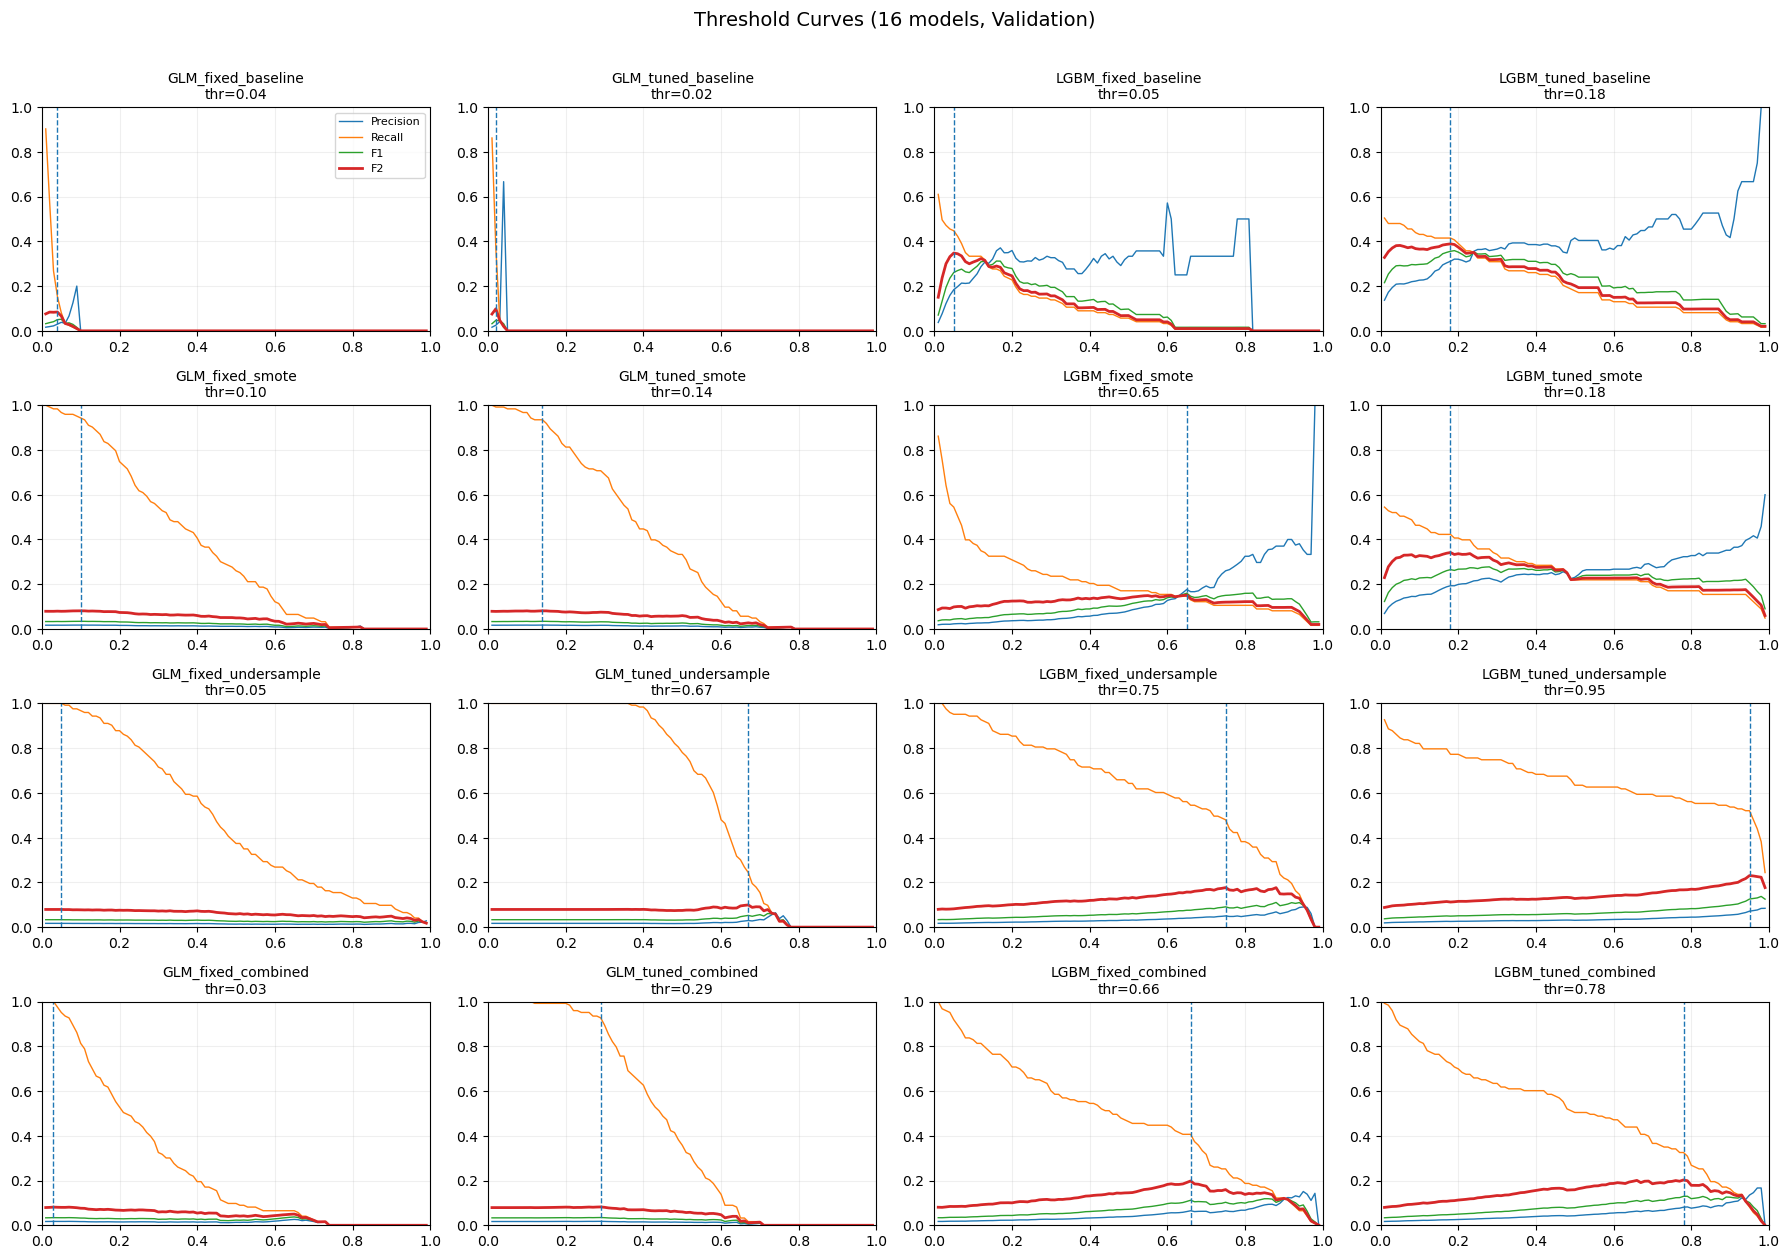

In [18]:
from CreditCardApproval.evaluation import plot_threshold_curves_grid

plot_threshold_curves_grid(
    models=models_16, X=X_val, y=y_val,
    optimal_thresholds=optimal_thresholds_16,
    title="Threshold Curves (16 models, Validation)",
    save_name="16_Threshold_Curves",
    ncols=4
)

Review: 

Threshold curves illustrate how key performance metrics, including precision, recall, F1, and F2, vary as the classification threshold changes. It highlights the trade-offs between identifying high-risk applicants and controlling false positives, and provide a practical basis for selecting decision thresholds aligned with credit risk management objectives.

Compared to GLM, the LGBM model maintains relatively stable F2 performance across a broader threshold range, demonstrating greater flexibility in risk identification. This suggests that in credit approval scenarios, threshold adjustments can effectively balance default detection capability with misclassification costs, thereby enhancing the model's practical application value.

In [19]:
from CreditCardApproval.evaluation import evaluate_models_table

model_evaluation_outcomes = evaluate_models_table(
    models=models_16,
    X=X_val,
    y=y_val,
    thresholds=optimal_thresholds_16,
    sort_by="auc",
    ascending=False
)

model_evaluation_outcomes

,model_name,threshold,auc,gini,ks,accuracy,precision,recall,f1,f2,tp,fp,tn,fn
0,LGBM_tuned_baseline,0.18,0.759969,0.519937,0.453570,0.974630,0.310976,0.414634,0.355401,0.388720,51,113,7056,72
1,LGBM_fixed_baseline,0.05,0.740954,0.481909,0.427306,0.957213,0.183946,0.447154,0.260664,0.347661,55,244,6925,68
2,LGBM_tuned_smote,0.18,0.723726,0.447453,0.457415,0.960505,0.193309,0.422764,0.265306,0.341656,52,217,6952,71
3,LGBM_tuned_undersample,0.95,0.722945,0.445890,0.404130,0.877674,0.071349,0.520325,0.125490,0.230382,64,833,6336,59
4,LGBM_fixed_undersample,0.75,0.708700,0.417400,0.338471,0.837767,0.050085,0.479675,0.090699,0.176647,59,1119,6050,64
5,LGBM_tuned_combined,0.78,0.702493,0.404987,0.363299,0.926221,0.080808,0.325203,0.129450,0.202634,40,455,6714,83
6,LGBM_fixed_combined,0.66,0.668393,0.336787,0.316313,0.891251,0.064935,0.406504,0.111982,0.198098,50,720,6449,73
7,LGBM_fixed_smote,0.65,0.612847,0.225694,0.176468,0.974081,0.176471,0.146341,0.160000,0.151515,18,84,7085,105
8,GLM_tuned_undersample,0.67,0.544905,0.089811,0.120646,0.851344,0.029383,0.243902,0.052448,0.099141,30,991,6178,93
9,GLM_tuned_baseline,0.02,0.543830,0.087661,0.132209,0.749589,0.025098,0.365854,0.046973,0.098468,45,1748,5421,78


In [20]:
tmp = model_evaluation_outcomes["model_name"].str.split("_", expand=True)
model_evaluation_outcomes.insert(1, "algo", tmp[0])
model_evaluation_outcomes.insert(2, "params", tmp[1])
model_evaluation_outcomes.insert(3, "sampling", tmp[2])

model_evaluation_outcomes

,model_name,algo,params,sampling,threshold,auc,gini,ks,accuracy,precision,recall,f1,f2,tp,fp,tn,fn
0,LGBM_tuned_baseline,LGBM,tuned,baseline,0.18,0.759969,0.519937,0.453570,0.974630,0.310976,0.414634,0.355401,0.388720,51,113,7056,72
1,LGBM_fixed_baseline,LGBM,fixed,baseline,0.05,0.740954,0.481909,0.427306,0.957213,0.183946,0.447154,0.260664,0.347661,55,244,6925,68
2,LGBM_tuned_smote,LGBM,tuned,smote,0.18,0.723726,0.447453,0.457415,0.960505,0.193309,0.422764,0.265306,0.341656,52,217,6952,71
3,LGBM_tuned_undersample,LGBM,tuned,undersample,0.95,0.722945,0.445890,0.404130,0.877674,0.071349,0.520325,0.125490,0.230382,64,833,6336,59
4,LGBM_fixed_undersample,LGBM,fixed,undersample,0.75,0.708700,0.417400,0.338471,0.837767,0.050085,0.479675,0.090699,0.176647,59,1119,6050,64
5,LGBM_tuned_combined,LGBM,tuned,combined,0.78,0.702493,0.404987,0.363299,0.926221,0.080808,0.325203,0.129450,0.202634,40,455,6714,83
6,LGBM_fixed_combined,LGBM,fixed,combined,0.66,0.668393,0.336787,0.316313,0.891251,0.064935,0.406504,0.111982,0.198098,50,720,6449,73
7,LGBM_fixed_smote,LGBM,fixed,smote,0.65,0.612847,0.225694,0.176468,0.974081,0.176471,0.146341,0.160000,0.151515,18,84,7085,105
8,GLM_tuned_undersample,GLM,tuned,undersample,0.67,0.544905,0.089811,0.120646,0.851344,0.029383,0.243902,0.052448,0.099141,30,991,6178,93
9,GLM_tuned_baseline,GLM,tuned,baseline,0.02,0.543830,0.087661,0.132209,0.749589,0.025098,0.365854,0.046973,0.098468,45,1748,5421,78


Review:

The meaning of each evaluation factor is:
* threshold: The probability cutoff used to classify applicants as default or non-default.
* AUC: Measures the model’s overall ability to rank higher-risk applicants above lower-risk ones.
* gini: A scaled version of AUC commonly used in credit risk to quantify discriminatory power.
* KS: Captures the maximum separation between good and bad customers across score distributions.
* accuracy: The proportion of correctly classified applicants across all observations.
* precision: The share of predicted defaulters that are truly default cases.
* recall: The proportion of actual defaulters correctly identified by the model.
* f1: The harmonic mean of precision and recall, balancing false positives and false negatives.
* f2: A recall-weighted metric that places greater emphasis on identifying defaulters.
* tp: Number of defaulters correctly identified as high risk.
* fp: Number of non-defaulters incorrectly classified as defaulters.
* tn: Number of non-defaulters correctly classified as low risk.
* fn: Number of defaulters incorrectly classified as non-defaulters.

Results indicate that:
1) Across all configurations, LGBM demonstrated significantly superior discrimination capabilities compared to GLM, achieving markedly higher validation set AUC values. This indicates that linear models struggle to effectively capture the complex credit risk structure within this dataset.
2) LGBM achieved the highest validation set AUC under the baseline scenario without resampling, exhibiting relatively balanced performance across metrics. This suggests that resampling methods did not yield stable improvements on this dataset and may instead introduce noise.
3) While undersampling and hybrid sampling significantly improved recall, they came at the cost of substantial accuracy decline. This resulted in excessively high misclassification costs, diminishing the model's practicality for real-world credit approval.
4) Balancing discriminative capability with business metric performance, the LGBM tuned baseline model with optimized thresholds achieved an optimal equilibrium between risk identification effectiveness and operational feasibility. It is therefore recommended as the final model.

***

### 6. Visualization

##### ① ROC Curve

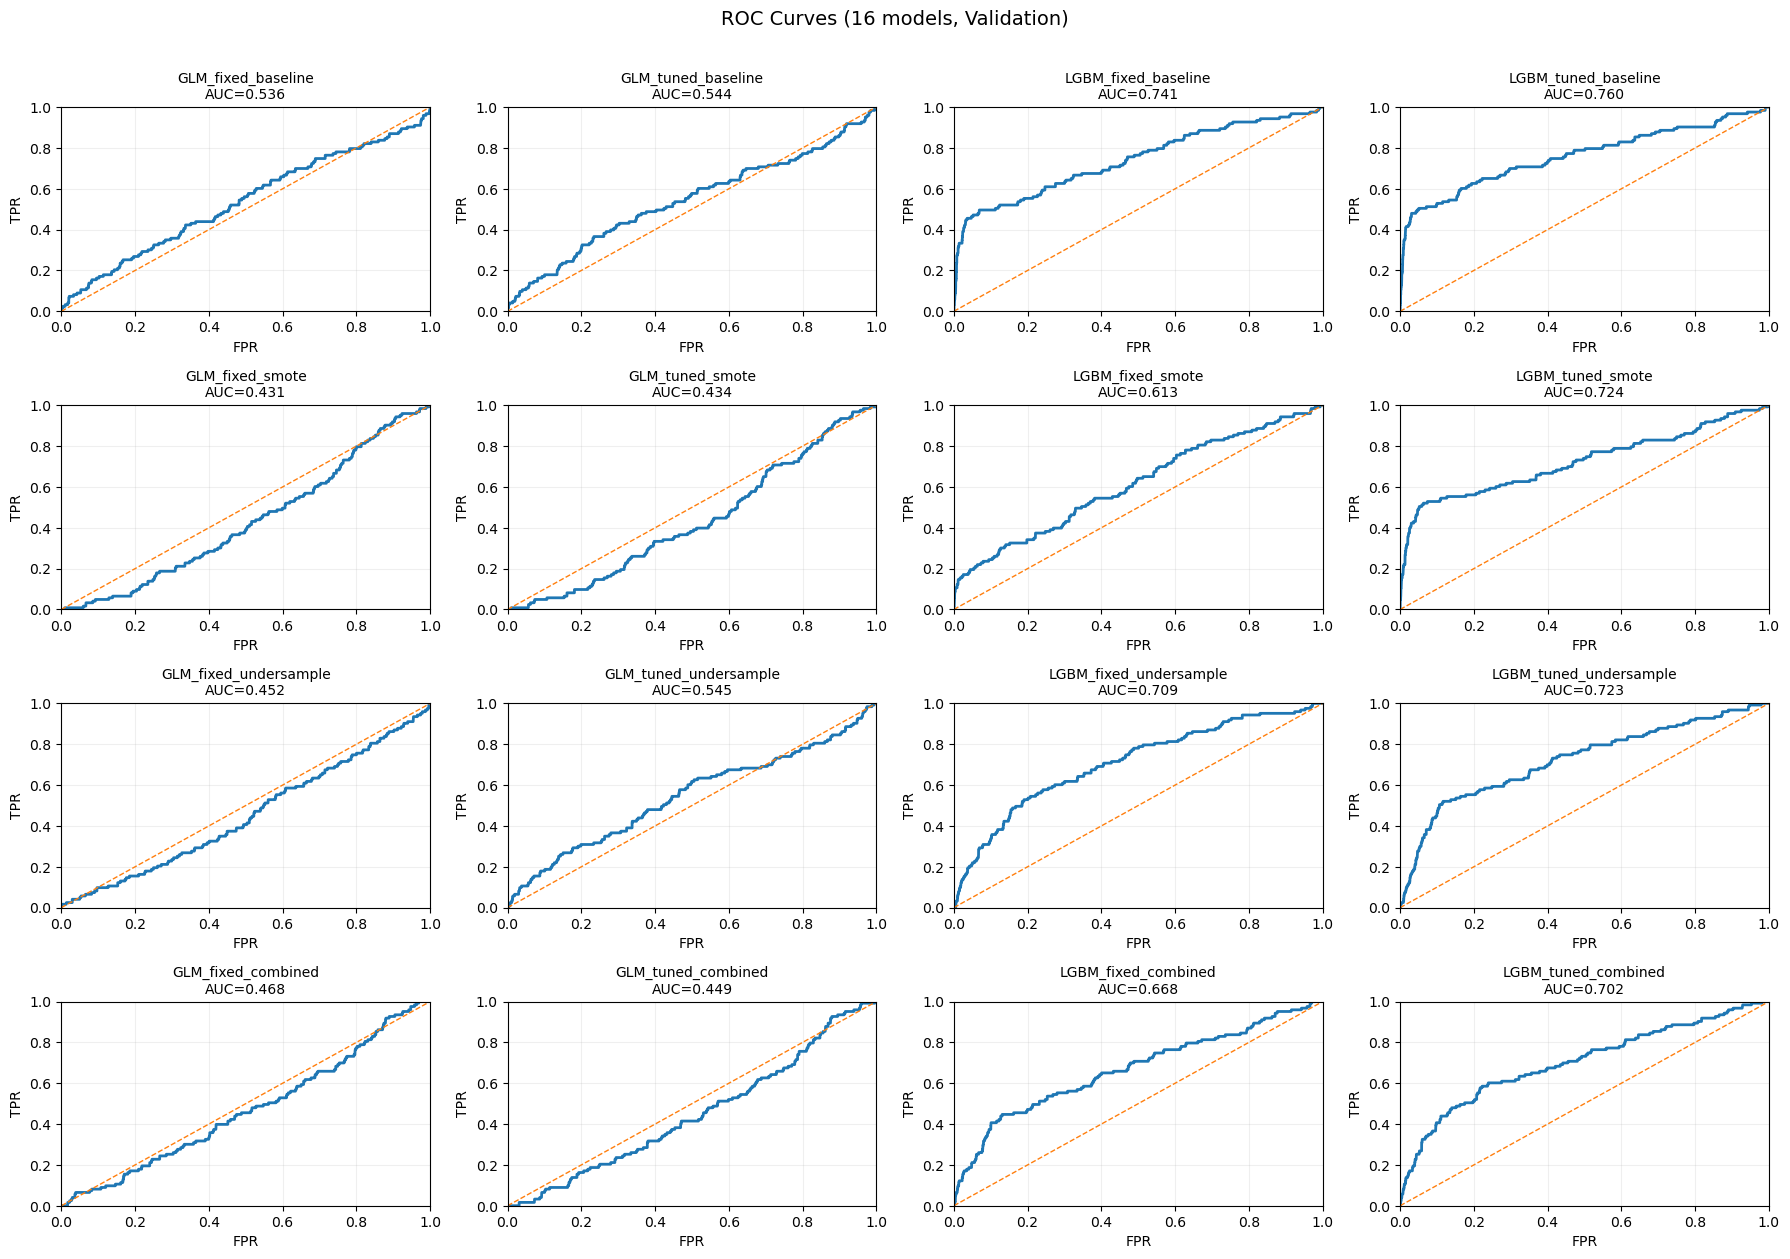

In [21]:
from CreditCardApproval.evaluation import plot_roc_curves_grid

plot_roc_curves_grid(
    models=models_16, X=X_val, y=y_val,
    title="ROC Curves (16 models, Validation)",
    save_name="16_ROC_Curves",
    ncols=4
)

Review:

The ROC curve characterizes the trade-off between true positive rate and false positive rate at different decision thresholds. Its area under the curve (AUC) reflects the model's overall ability to distinguish high-quality from low-quality customers, independent of specific threshold settings.

Results indicate that:
1) The ROC curve for the LGBM model consistently outperforms GLM, with a significantly larger AUC, demonstrating superior discrimination capabilities across varying risk preferences.
2) Consistent with prior findings, the LGBM model trained on the original sample distribution and optimized through parameter tuning exhibits optimal stability and discriminative power.

##### ② Confusion Matrix

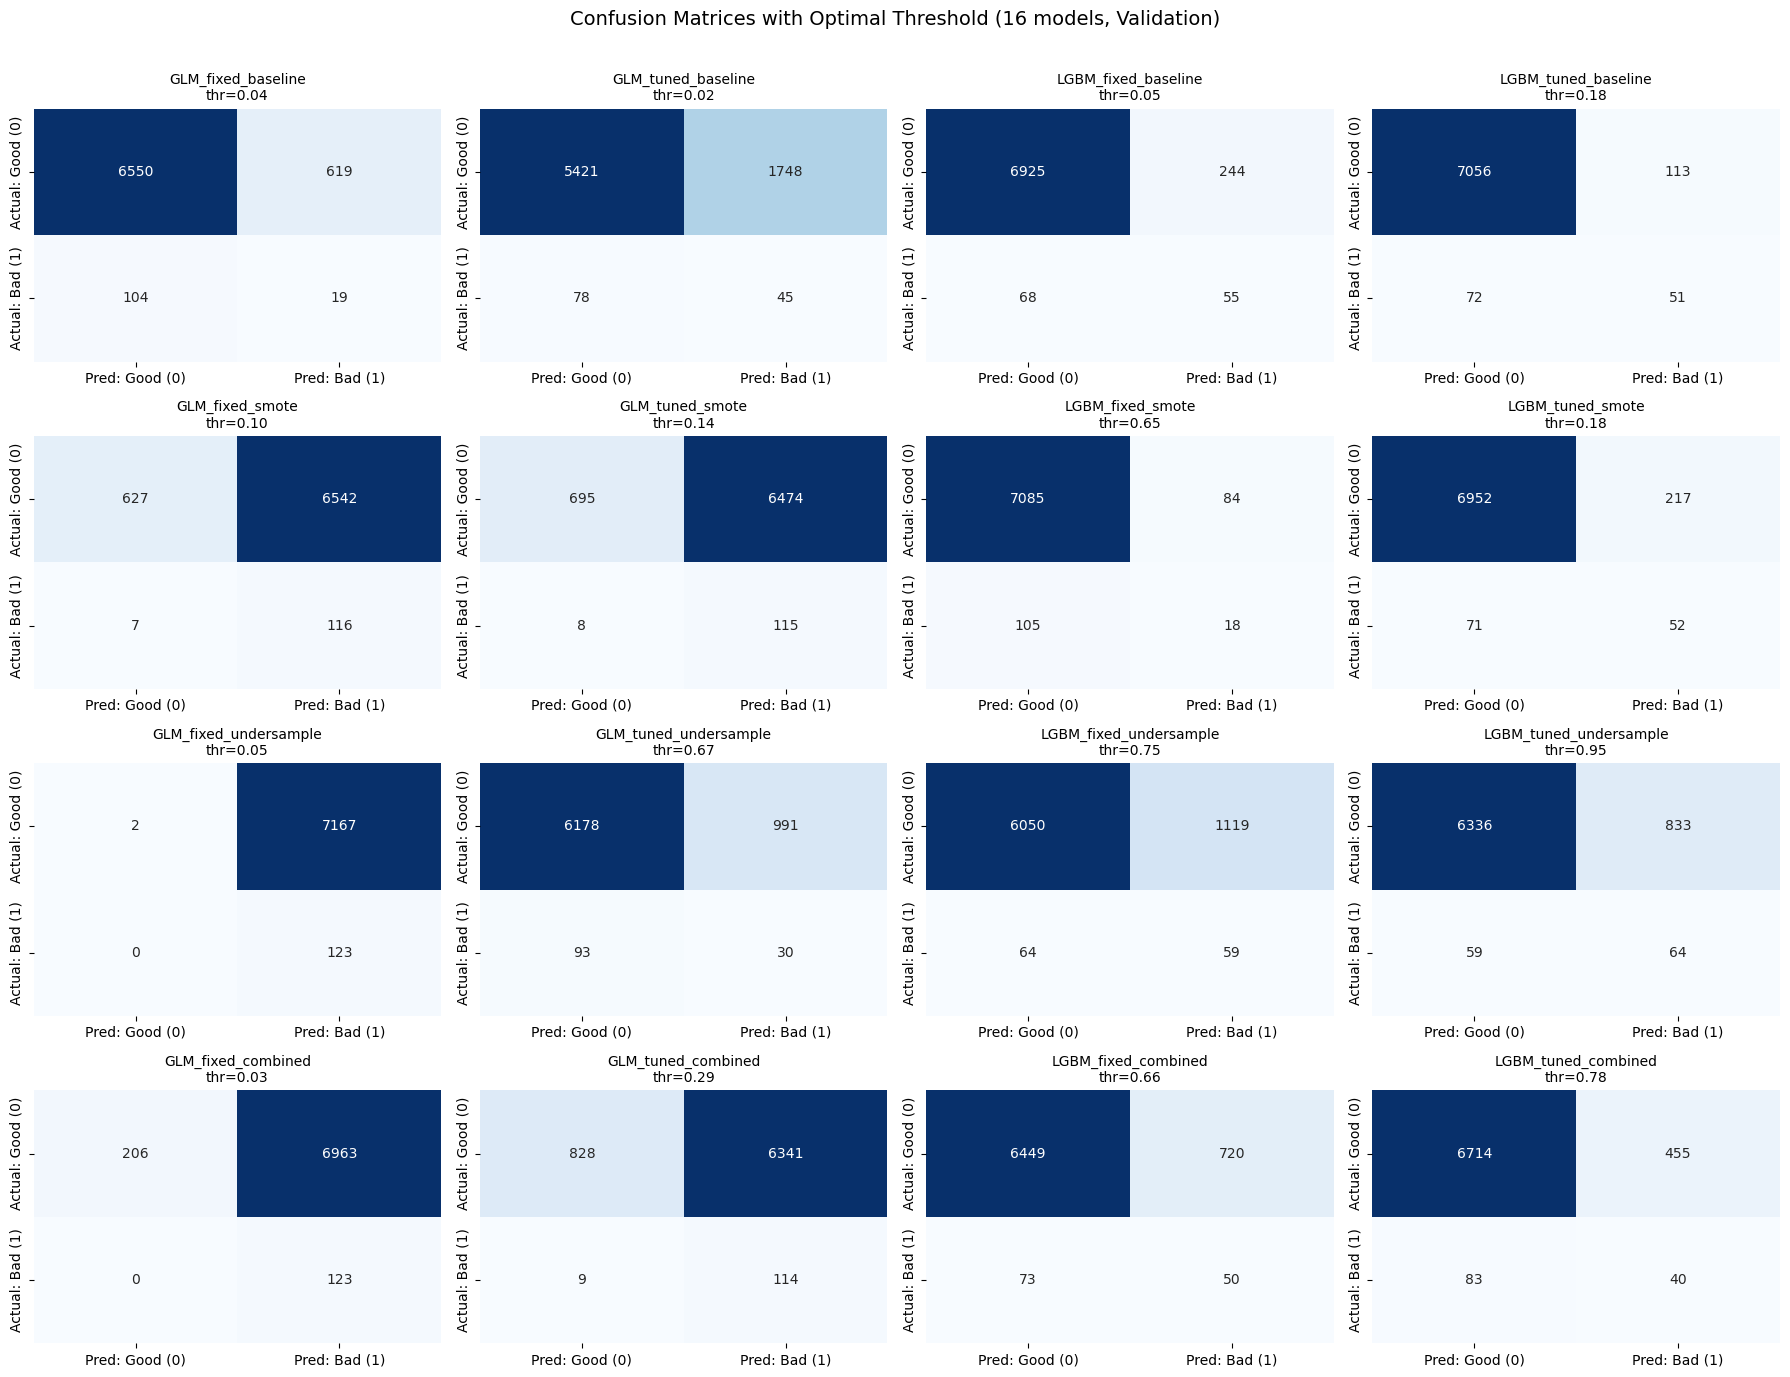

In [22]:
from CreditCardApproval.evaluation import plot_confusion_matrices_grid

plot_confusion_matrices_grid(
    models=models_16, X=X_val, y=y_val,
    thresholds=optimal_thresholds_16,
    title="Confusion Matrices with Optimal Threshold (16 models, Validation)",
    save_name="16_Confusion_Matrices",
    ncols=4
)

Review:

Confusion matrices provide a visual representation of a model's classification results for high-quality versus low-quality customers at a given decision threshold. They reflect the number of defaults identified, the rate of false rejections of high-quality customers, and potential risk exposure, serving as a crucial basis for evaluating a model's actual risk control effectiveness.

Aligning with prior findings, LGBM tuned baseline maintains strong default detection capability while effectively controlling misclassification rates among high-quality customers, demonstrating balanced risk trade-offs. In contrast, some resampling models identify more high-risk customers but generate substantial misclassifications, increasing unnecessary rejection costs and limiting their practical applicability in credit approval workflows.

##### ③ Compare predicted and actual data

Based on previous model comparasion, a baseline model with hyperparameter tuning is adopted as a benchmark model for both GLM and LGBM.

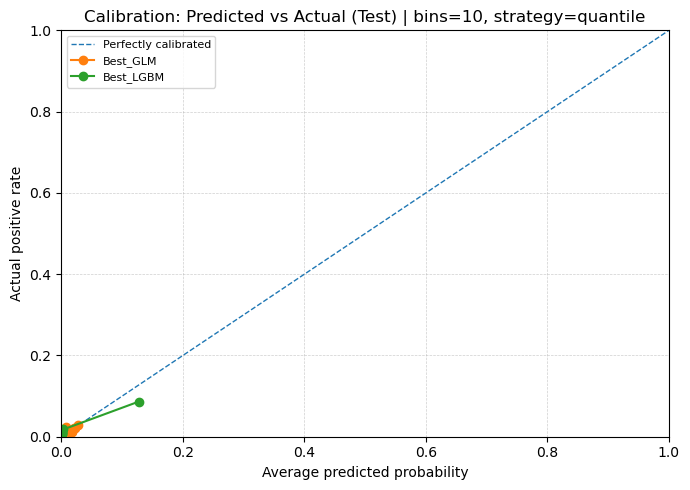

,bin,n,actual_rate,avg_pred,min_pred,max_pred,model,n_bins_used
0,"(0.00284, 0.01]",730,0.023288,0.008053,3.835227e-03,0.010036,Best_GLM,10
1,"(0.01, 0.012]",732,0.015027,0.011049,1.004150e-02,0.011969,Best_GLM,10
2,"(0.012, 0.0135]",726,0.011019,0.012693,1.197126e-02,0.013451,Best_GLM,10
3,"(0.0135, 0.0148]",729,0.012346,0.014170,1.345227e-02,0.014844,Best_GLM,10
4,"(0.0148, 0.0161]",729,0.010974,0.015524,1.484982e-02,0.016140,Best_GLM,10
5,"(0.0161, 0.0175]",732,0.013661,0.016803,1.614025e-02,0.017523,Best_GLM,10
6,"(0.0175, 0.019]",727,0.011004,0.018240,1.752350e-02,0.019045,Best_GLM,10
7,"(0.019, 0.0211]",728,0.021978,0.019981,1.904614e-02,0.021085,Best_GLM,10
8,"(0.0211, 0.0242]",729,0.020576,0.022537,2.108740e-02,0.024218,Best_GLM,10
9,"(0.0242, 0.0525]",730,0.028767,0.027791,2.422698e-02,0.052500,Best_GLM,10


In [24]:
from CreditCardApproval.evaluation import plot_predicted_vs_actual

best_glm_model = glm_models_tuned["baseline"]
best_lgbm_model = lgbm_models_tuned["baseline"]

final_models = {
    "Best_GLM": best_glm_model,
    "Best_LGBM": best_lgbm_model,
}

calib_table = plot_predicted_vs_actual(
    final_models,
    X_val,
    y_val,
    n_bins=10,
    strategy="quantile",
    title="Calibration: Predicted vs Actual",
    save_name="2_predicted_actual_calibration"
)

calib_table

Review:

The calibration curve assesses the consistency between the model's predicted default probabilities and actual occurrence rates. The closer the curve aligns with the diagonal line, the more accurately the model's risk probabilities reflect the customer's credit quality.

Results indicate that:
1) GLM's predicted probabilities closely match actual default rates across all bins, demonstrating overall good calibration. This highlights the stability of linear models in probability interpretation.
2) LGBM significantly underestimates default probabilities in low-risk intervals while exhibiting a more concentrated probability distribution in high-risk bins, suggesting its greater emphasis on risk ranking rather than probability characterization.

GLM demonstrates greater robustness in probabilistic characterization and stability, while LGBM exhibits distinct advantages in credit risk ranking and discrimination capabilities. Within risk control systems, the two models play complementary roles. Hence,despite LGBM's superior discriminative capability, practical risk control applications still necessitate calibration to enhance the interpretability and operational usability of its probability outputs.

##### ④ Feature importance

In [25]:
from CreditCardApproval.evaluation import get_glm_feature_importance

glm_imp = get_glm_feature_importance(best_glm_model, top_k=10)
print(f"Feature importance of GLM:\n")
glm_imp

Feature importance of GLM:



,feature,coef,abs_coef
0,cat__own_realty_N,0.331271,0.331271
1,cat__gender_M,0.298846,0.298846
2,cat__income_type_Retired,0.287417,0.287417
3,cat__own_car_N,0.253179,0.253179
4,num__employed_years,-0.239428,0.239428
5,cat__family_status_Previously_Married,0.215487,0.215487
6,cat__housing_status_Own_Home,0.198692,0.198692
7,cat__family_status_Single,0.196095,0.196095
8,cat__housing_status_Rental,0.158338,0.158338
9,cat__education_level_Secondary,0.156681,0.156681


In [26]:
from CreditCardApproval.evaluation import get_lgbm_feature_importance

lgbm_imp = get_lgbm_feature_importance(best_lgbm_model, top_k=10)
print(f"\nFeature importance of LGBM:\n")
lgbm_imp


Feature importance of LGBM:



,feature,importance
0,num__age_years,7698
1,num__employed_years,5364
2,num__annual_income,4473
3,num__family_size,714
4,num__own_phone,622
5,num__own_work_phone,516
6,cat__own_realty_N,466
7,cat__gender_F,416
8,cat__own_car_N,413
9,num__children_number,387


Review:

Feature importance analysis identifies the primary information sources relied upon by the model during credit risk assessment. In this context, GLM coefficients reflect the linear direction and strength of a variable's impact on default probability, while LGBM importance measures a feature's contribution to risk differentiation during tree model splitting.

Results indicate that: 
1) GLM relies more heavily on asset and social attribute variables—such as property/vehicle ownership, employment tenure, and family/marital status—demonstrating its linear modeling capability for customer stability and long-term credit characteristics.
2) LGBM emphasizes continuous variables and nonlinear relationships, with age, employment tenure, and income level playing dominant roles in risk differentiation, highlighting its advantage in capturing complex interaction effects.

The differing emphasis on features between the two models further validates their complementary roles in credit risk assessment—one emphasizing interpretability and the other emphasizing discrimination capability.